In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from src.eval import *

models = ['rtf', 'rctgan', 'tabula']
sample_sizes = [10, 100, 500, 1000, 5000, 10000]
results = []

for model in models:
    base_path = Path(f"../results/{model}_retail")
    dfs = {"Test": pd.read_csv("../data/sampled/retail_test_1000.csv")}

    for size in sample_sizes:
        train_path = f"../data/sampled/retail_sample_{size}.csv"
        syn_path = base_path / f"train{size}" / f"syn_{model}_1000.csv"
        
        dfs[f"train{size}"] = pd.read_csv(train_path)
        dfs[f"syn{size}"] = pd.read_csv(syn_path)

    num_cols = ['Quantity', 'UnitPrice']
    cat_cols = ['Country', 'Description']
    dfs_transformed, _ = preprocess(dfs, num_cols, cat_cols)

    for size in sample_sizes:
        real_vec = dfs_transformed[f"train{size}"]
        real_table = dfs[f"train{size}"]

        syn_vec = dfs_transformed[f"syn{size}"]
        syn_table = dfs[f"syn{size}"]
        
        print(f"\n{model} - train{size}")
        dcr_values, nndr_score, cap_desc, cap_quant, dpe_score = calculate_metrics(real_vec, syn_vec, real_table, syn_table)
        save_dcr_list(dcr_values, model, size)
        dcr_median = np.median(dcr_values) if isinstance(dcr_values, (list, np.ndarray)) else dcr_values
        results.append({
            'Model': model,
            'Sample Size': size,
            'DCR': dcr_median,
            'NNDR': nndr_score,
            'CAP_Description': cap_desc,
            'CAP_Quantity': cap_quant,
            'DPE': dpe_score
        })

results_df = pd.DataFrame(results)
results_df.set_index(['Model', 'Sample Size'], inplace=True)
results_df.to_csv("../results/summary.csv")
results_df


모델: rtf - train10


Computing DCR: 100%|██████████| 15/15 [00:02<00:00,  7.14it/s]


DCR Median: 0.7382
최소 거리: 0.0000, 최대 거리: 3.1455


Computing NNDR: 100%|██████████| 15/15 [00:00<00:00, 15.64it/s]


NNDR (median dist_1 / dist_2): 0.8430


...

DCR Median: 0.0000
최소 거리: 0.0000, 최대 거리: 112.0574


Computing NNDR: 100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


NNDR (median dist_1 / dist_2): 0.0000


Estimating Disclosure Protection (Score=0.999): 100%|██████████| 10/10 [00:06<00:00,  1.62it/s]


DCR      NNDR  CAP_Description  CAP_Quantity  \
Model  Sample Size                                                      
rtf    10           0.738185  0.842991           0.9937        0.9068   
       100          0.426603  0.936487           0.9991        0.9293   
       500          0.316995  0.999902           0.9990        0.8747   
       1000         0.396244  1.000000           0.9976        0.8864   
       5000         0.303010  1.000000           0.9980        0.8843   
       10000        0.000000  0.000000           0.9983        0.9043   
rctgan 10           1.417194  0.961036           0.9936        0.9303   
       100          1.030140  0.981926           0.9990        0.8988   
       500          1.018967  0.987944           0.9993        0.9186   
       1000         1.008757  0.996573           0.9993        0.9153   
       5000         0.608705  1.000000           0.9991        0.9584   
       10000        0.505829  1.000000           0.9991        0.9259   
tabula 10           0.348066  0.348066           0.9932        0.7293   
       100          0.348551  0.863847           0.9992        0.8670   
       500          0.309548  0.999162           0.9986        0.8718   
       1000         0.146843  1.000000           0.9987        0.8690   
       5000         0.000000  0.000000           0.9988        0.9064   
       10000        0.000000  0.000000           0.9988        0.9123   

                         DPE  
Model  Sample Size            
rtf    10           1.000000  
       100          0.999868  
       500          0.999451  
       1000         0.997931  
       5000         0.998246  
       10000        0.998535  
rctgan 10           0.999931  
       100          0.999827  
       500          0.999732  
       1000         0.999613  
       5000         0.999428  
       10000        0.999346  
tabula 10           0.999529  
       100          0.999891  
       500          0.999014  
       1000         0.999086  
       5000         0.999165  
       10000        0.999163

In [3]:
results_df

DCR      NNDR  CAP_Description  CAP_Quantity  \
Model  Sample Size                                                      
rtf    10           0.738185  0.842991           0.9937        0.9068   
       100          0.426603  0.936487           0.9991        0.9293   
       500          0.316995  0.999902           0.9990        0.8747   
       1000         0.396244  1.000000           0.9976        0.8864   
       5000         0.303010  1.000000           0.9980        0.8843   
       10000        0.000000  0.000000           0.9983        0.9043   
rctgan 10           1.417194  0.961036           0.9936        0.9303   
       100          1.030140  0.981926           0.9990        0.8988   
       500          1.018967  0.987944           0.9993        0.9186   
       1000         1.008757  0.996573           0.9993        0.9153   
       5000         0.608705  1.000000           0.9991        0.9584   
       10000        0.505829  1.000000           0.9991        0.9259   
tabula 10           0.348066  0.348066           0.9932        0.7293   
       100          0.348551  0.863847           0.9992        0.8670   
       500          0.309548  0.999162           0.9986        0.8718   
       1000         0.146843  1.000000           0.9987        0.8690   
       5000         0.000000  0.000000           0.9988        0.9064   
       10000        0.000000  0.000000           0.9988        0.9123   

                         DPE  
Model  Sample Size            
rtf    10           1.000000  
       100          0.999868  
       500          0.999451  
       1000         0.997931  
       5000         0.998246  
       10000        0.998535  
rctgan 10           0.999931  
       100          0.999827  
       500          0.999732  
       1000         0.999613  
       5000         0.999428  
       10000        0.999346  
tabula 10           0.999529  
       100          0.999891  
       500          0.999014  
       1000         0.999086  
       5000         0.999165  
       10000        0.999163

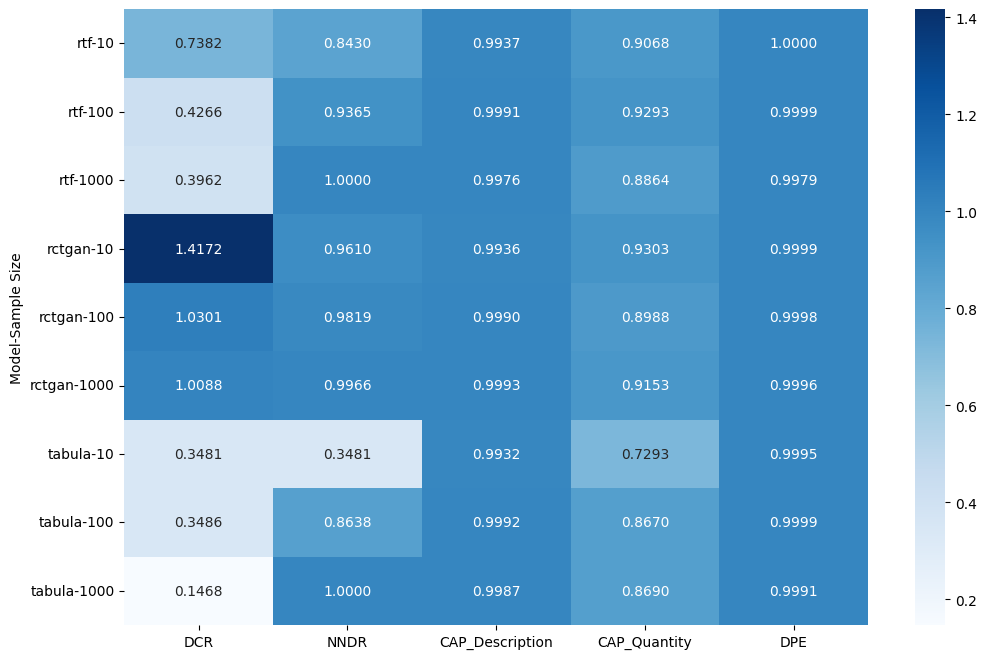

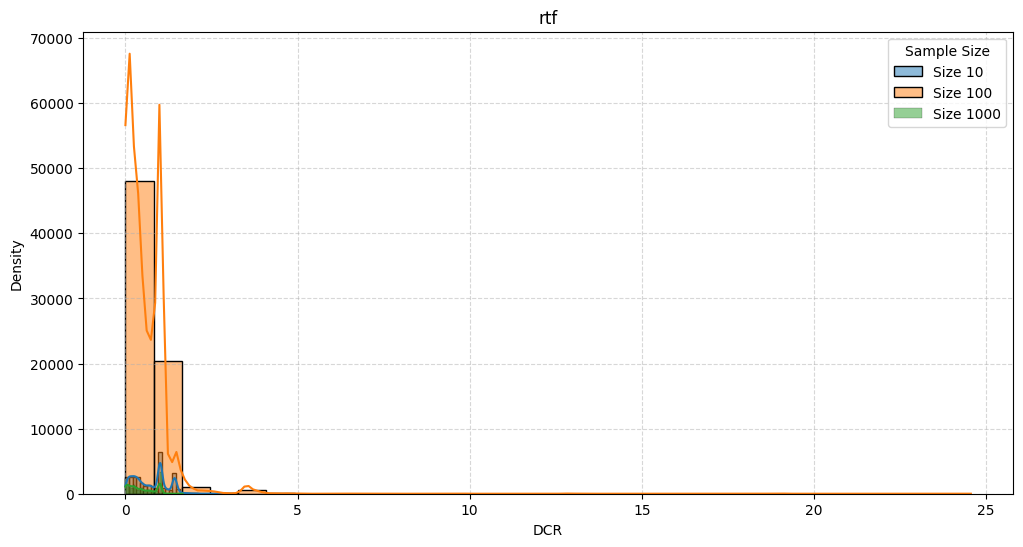

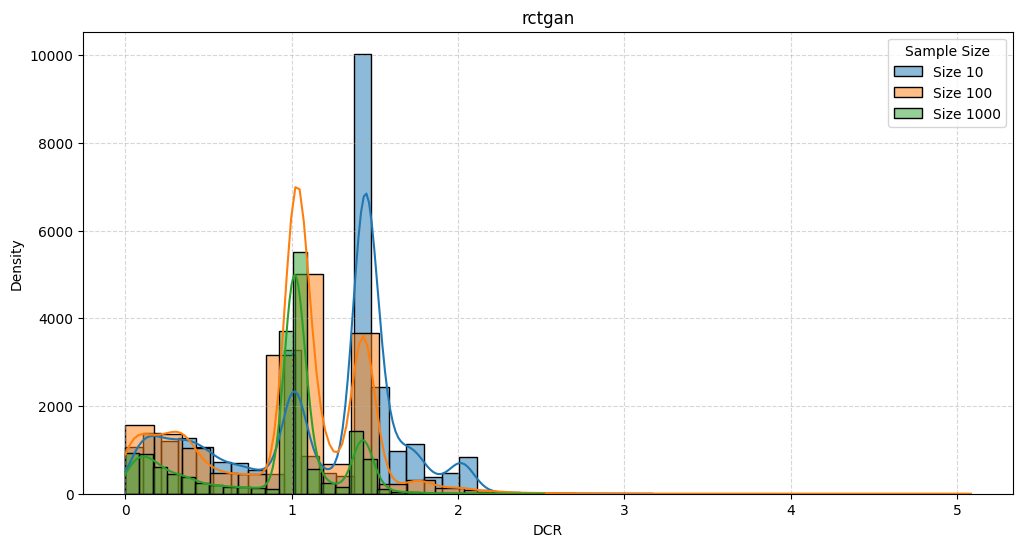

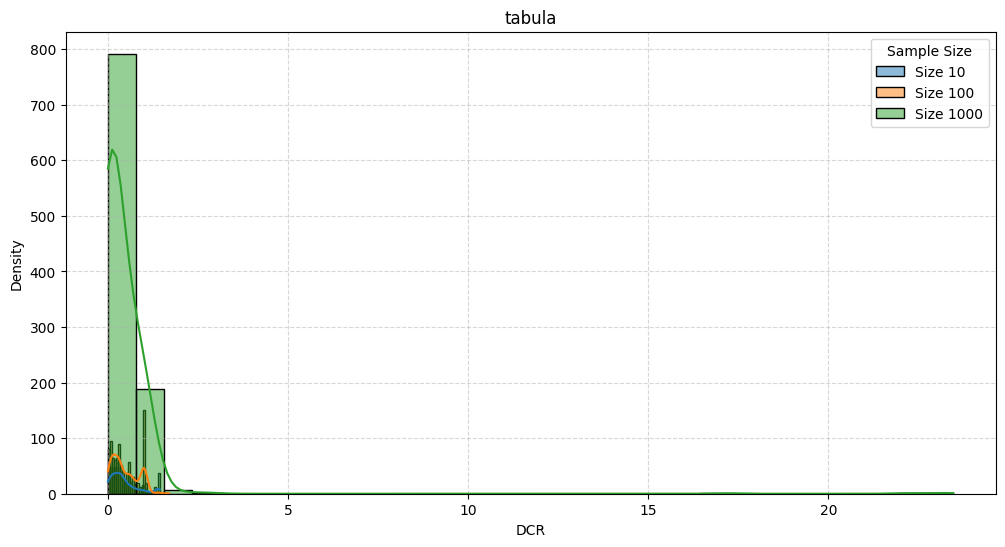

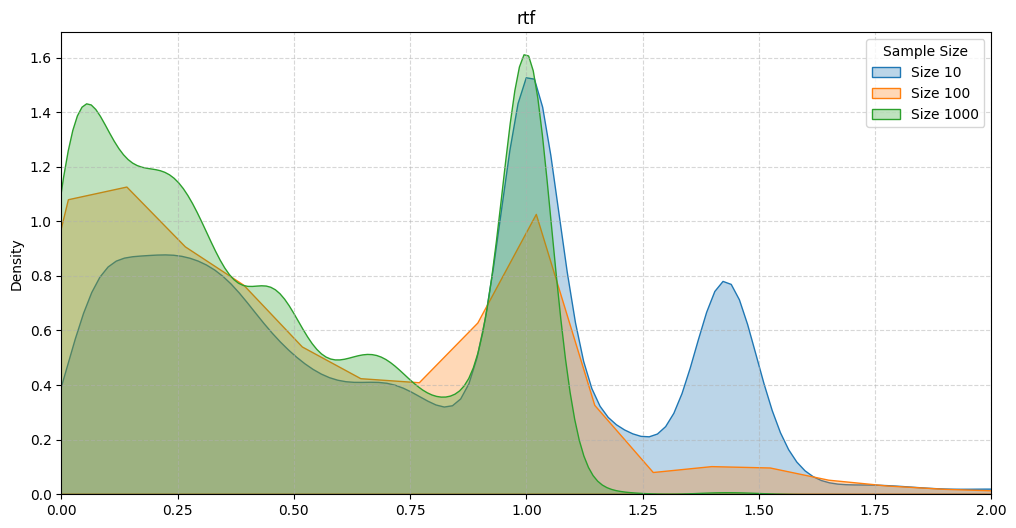

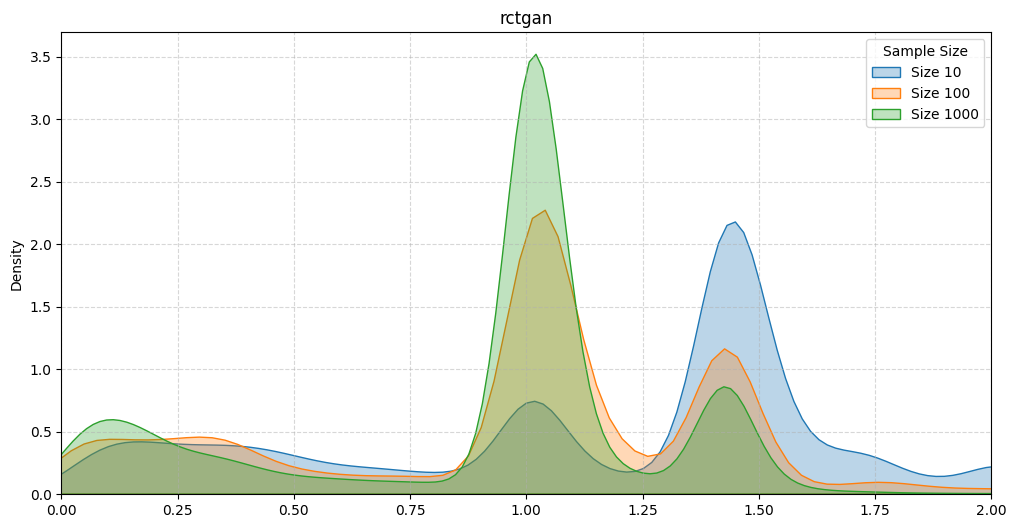

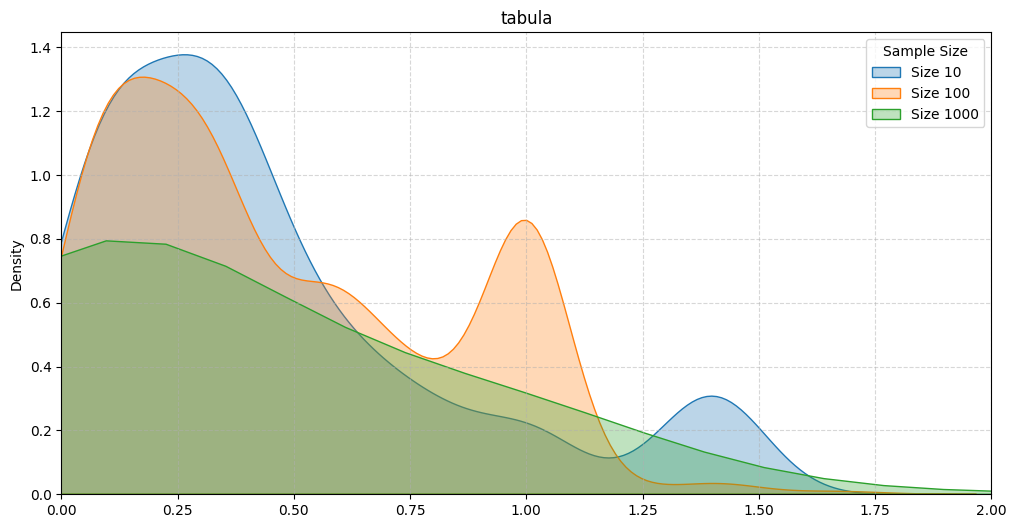

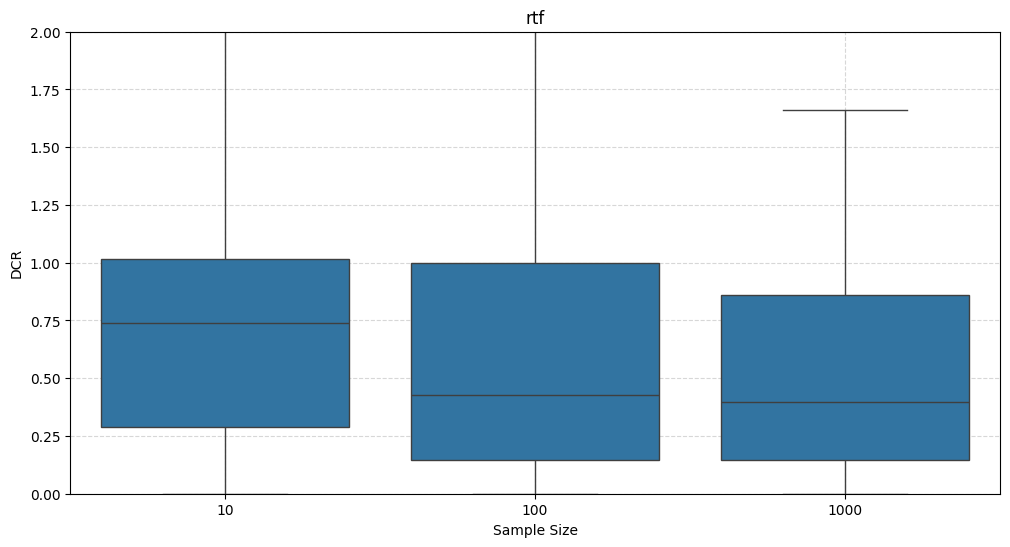

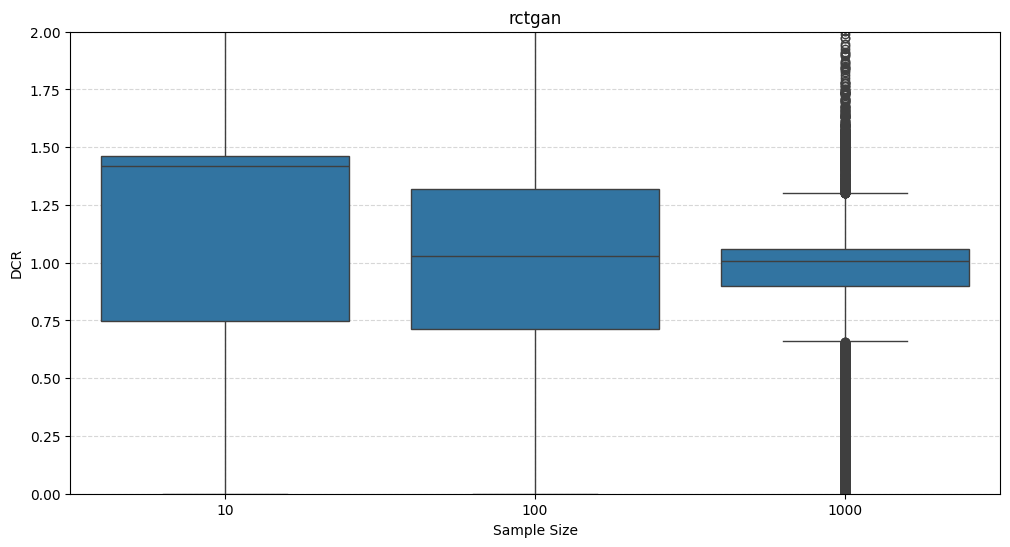

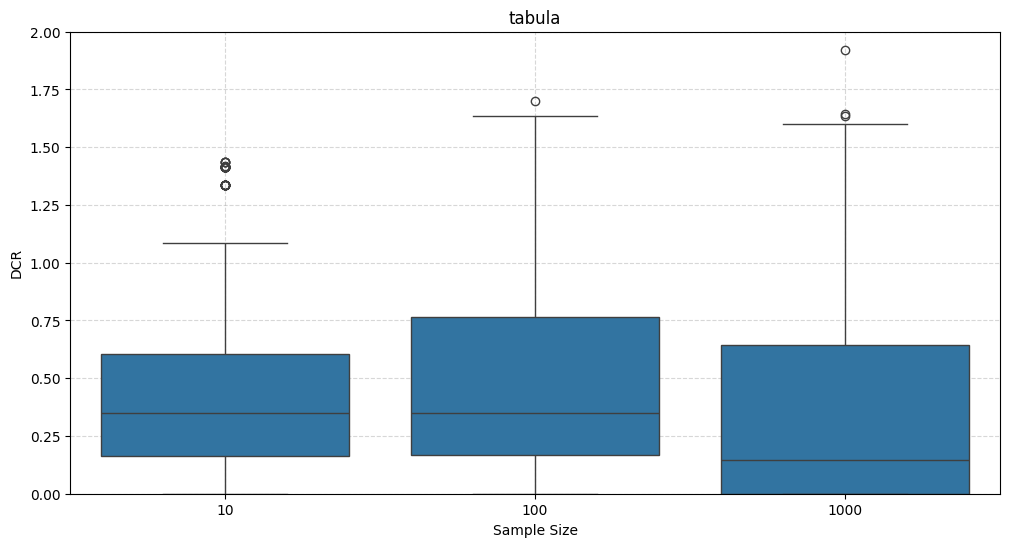

In [ ]:
sub_df = results_df.loc[results_df.index.get_level_values('Sample Size').isin([10, 100, 1000, 10000])]
plot_heatmap(sub_df)
plot_dcr_histograms(sub_df)
plot_dcr_kde(sub_df)
plot_dcr_boxplot(sub_df)

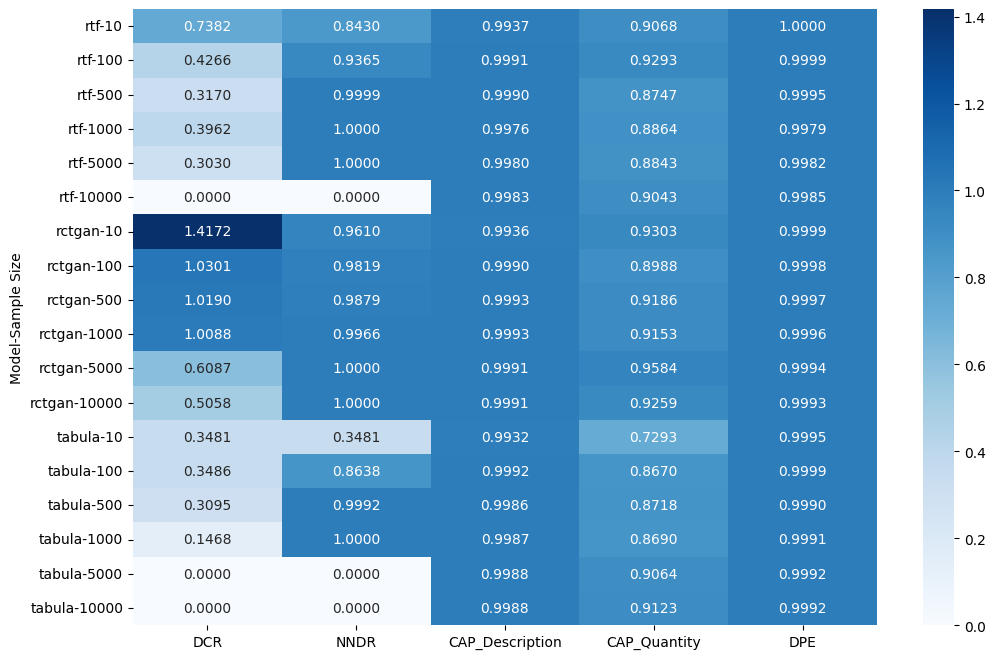

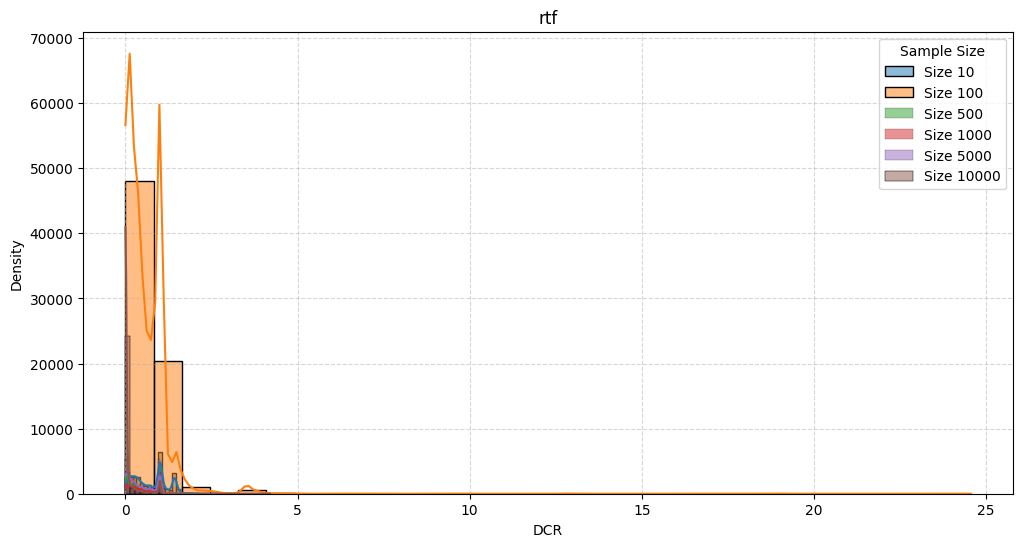

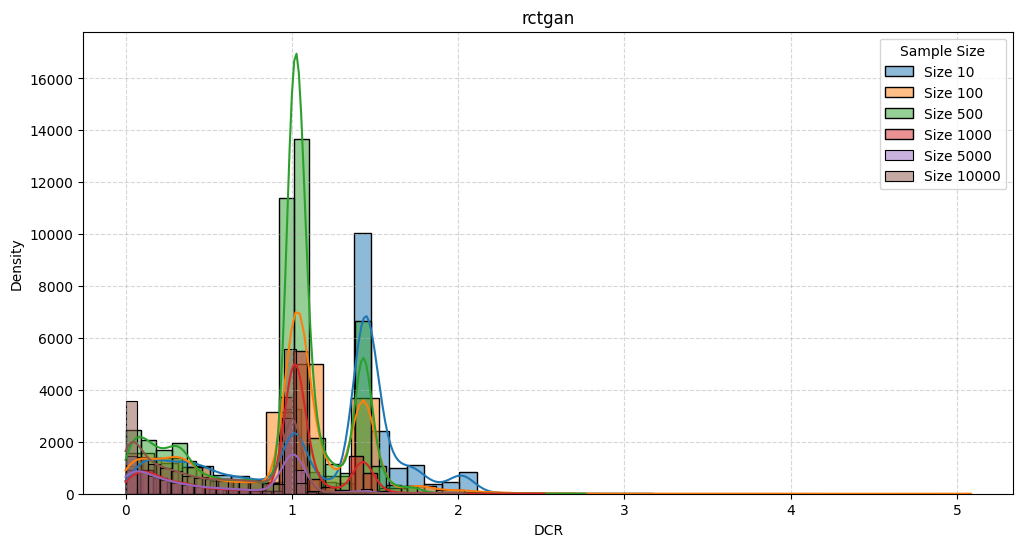

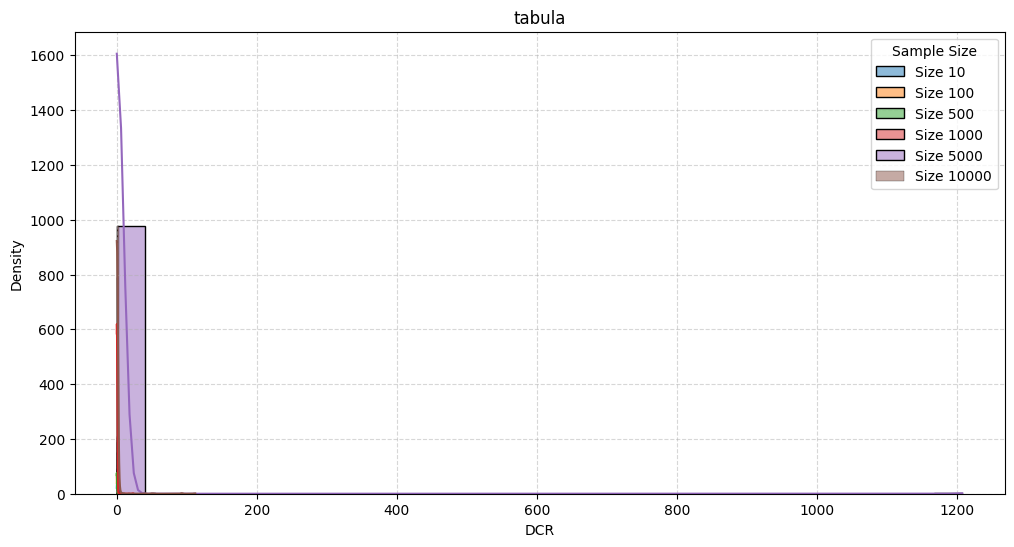

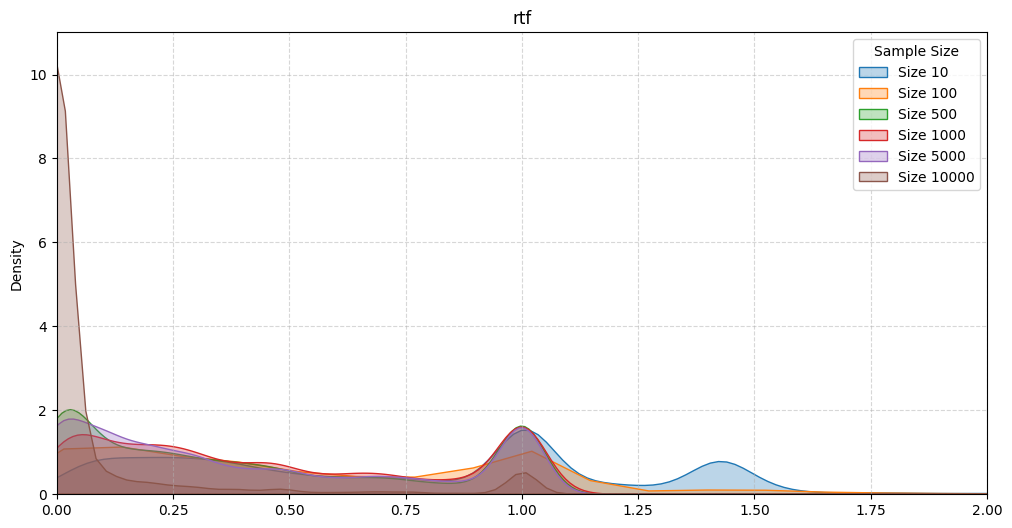

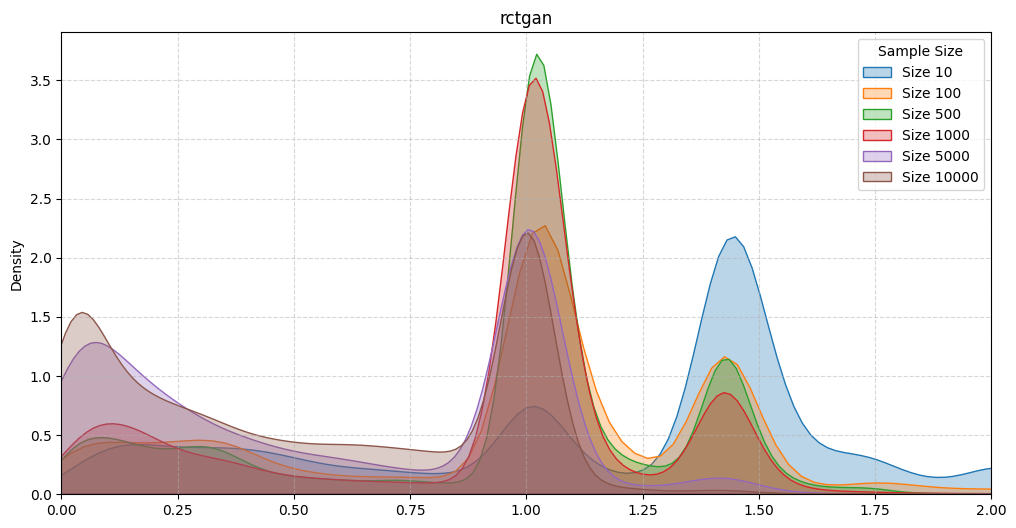

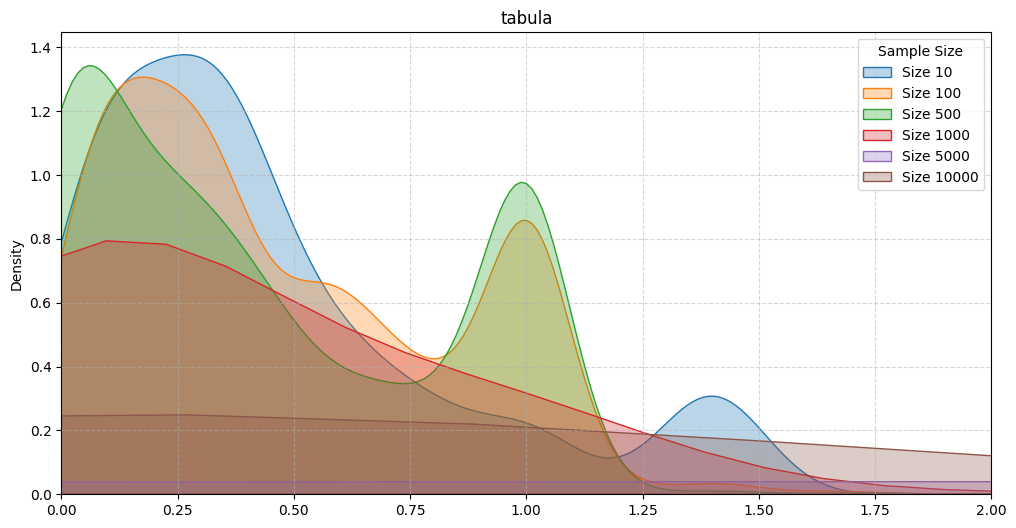

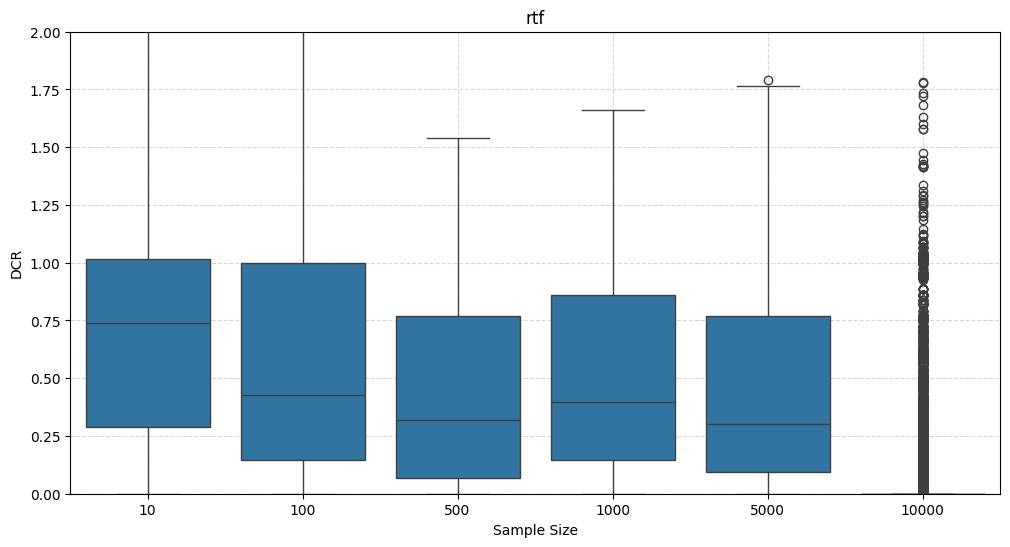

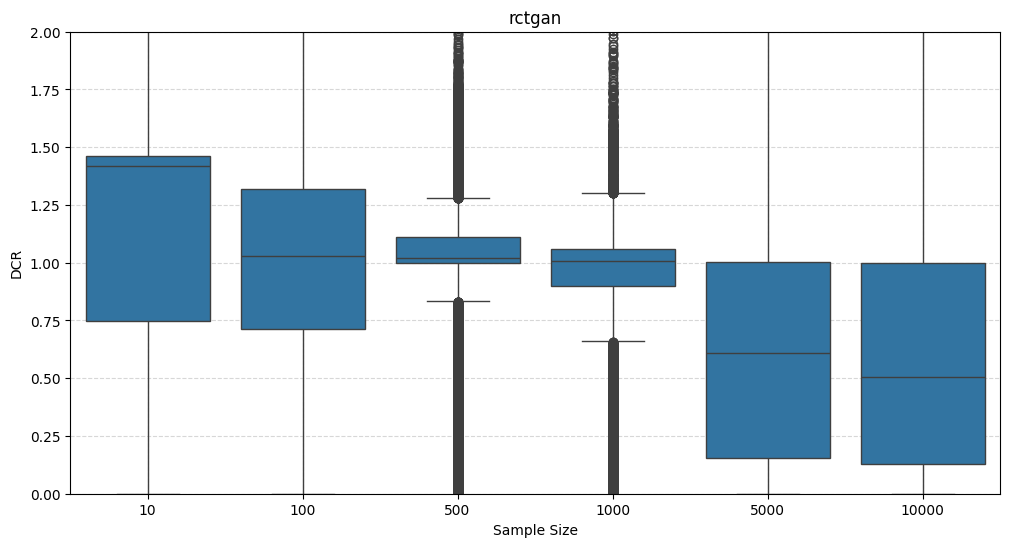

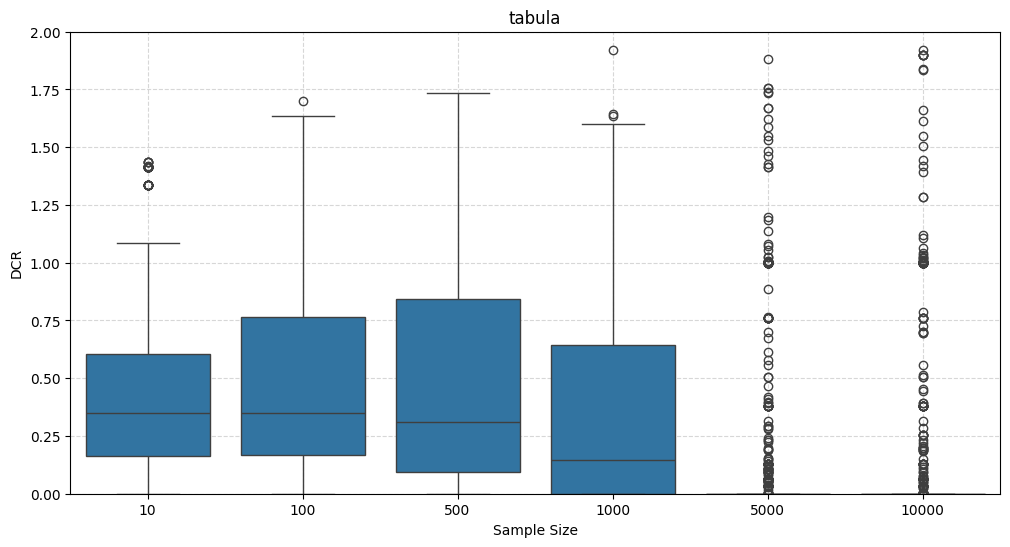

In [2]:
plot_heatmap(results_df)
plot_dcr_histograms(results_df)
plot_dcr_kde(results_df)
plot_dcr_boxplot(results_df)

In [ ]:
# heatmap_data = results_df.select_dtypes(include=[np.number])
# plt.figure(figsize=(12, 8))
# sns.heatmap(heatmap_data, cmap='Blues', annot=True, fmt=".4f")
# plt.show()

In [ ]:
# dcr_results = {}

# real_vec = dfs_transformed['Test']
# for size in sample_sizes:
#     syn_vec = dfs_transformed[f"train{size}"]
#     print(f"\n[train{size}]")
#     dcr_results[size] = dcr(real_vec, syn_vec)

# nndr_results = {}
# real_vec = dfs_transformed['Test']
# for size in sample_sizes:
#     syn_vec = dfs_transformed[f"train{size}"]
#     print(f"\n[train{size}]")
#     nndr_results[size] = nndr(real_vec, syn_vec)

# cap_results = {}
# for size in sample_sizes:
#     syn = dfs[f"train{size}"]
#     print(f"\n[train{size}]")
#     cap_results[size] = evaluate_categorical_cap(real_table=real, dfs=dfs)

# dpe_results = {}
# for size in sample_sizes:
#     syn = dfs[f"train{size}"]
#     print(f"\n[train{size}]")
#     dpe_results[size] = DisclosureProtectionEstimate.compute(
#         real_data=real,
#         synthetic_data=syn,
#         known_column_names=['Country'],
#         sensitive_column_names=['Description'],
#         num_rows_subsample=2500,
#         num_iterations=100,
#         verbose=True
#     )


In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
from src.eval import *

models = ['rtf', 'rctgan', 'tabula']
sample_sizes = [10, 100, 500, 1000, 5000, 10000]
results = []

for model in models:
    base_path = Path(f"../results/{model}_retail")
    dfs = {"Test": pd.read_csv("../data/sampled/retail_test_1000.csv")}

    for size in sample_sizes:
        train_path = f"../data/sampled/retail_sample_{size}.csv"
        dfs[f"train{size}"] = pd.read_csv(train_path)

    num_cols = ['Quantity', 'UnitPrice']
    cat_cols = ['Country', 'Description']
    dfs_transformed, _ = preprocess(dfs, num_cols, cat_cols)

    for size in sample_sizes:
        real_vec = dfs_transformed[f"train{size}"]
        real_table = dfs[f"train{size}"]

        syn_vec = dfs_transformed[f"Test"]
        syn_table = dfs[f"Test"]
        
        print(f"\n{model} - train{size}")
        dcr_values, nndr_score, cap_desc, cap_quant, dpe_score = calculate_metrics(real_vec, syn_vec, real_table, syn_table)
        save_dcr_list(dcr_values, model, size)
        dcr_median = np.median(dcr_values) if isinstance(dcr_values, (list, np.ndarray)) else dcr_values
        results.append({
            'Model': model,
            'Sample Size': size,
            'DCR': dcr_median,
            'NNDR': nndr_score,
            'CAP_Description': cap_desc,
            'CAP_Quantity': cap_quant,
            'DPE': dpe_score
        })

results_df_test = pd.DataFrame(results)
results_df_test.set_index(['Model', 'Sample Size'], inplace=True)
results_df_test.to_csv("../results/summary_test.csv")
results_df_test


rtf - train10


Computing DCR: 100%|██████████| 10/10 [00:01<00:00,  8.77it/s]


DCR Median: 1.0055
최소 거리: 0.0000, 최대 거리: 34.3218


Computing NNDR: 100%|██████████| 10/10 [00:00<00:00, 11.40it/s]


NNDR (median dist_1 / dist_2): 0.9972


...


rtf - train5000


Computing DCR: 100%|██████████| 10/10 [00:11<00:00,  1.10s/it]


DCR Median: 0.0000
최소 거리: 0.0000, 최대 거리: 1.7132


Computing NNDR: 100%|██████████| 10/10 [00:10<00:00,  1.08s/it]


NNDR (median dist_1 / dist_2): 0.0000
